In [ ]:
print("Hello Sanjana!")

Hello Sanjana!


import pandas as pd
import numpy as np

print("Libraries imported successfully!")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [4]:
import pandas as pd

df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
X = df.drop("target", axis=1)
y = df["target"]

print(X.head())
print(y.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  
0   0     1  
1   0     2  
2   0     2  
3   0     2  
4   0     2  
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (242, 13)
Testing data: (61, 13)


In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8360655737704918


In [9]:
predictions = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.head(10)

,Actual,Predicted
179,0,0
228,0,1
111,1,1
246,0,0
60,1,1
9,1,1
119,1,1
223,0,0
268,0,0
33,1,0


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[24  5]
 [ 5 27]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



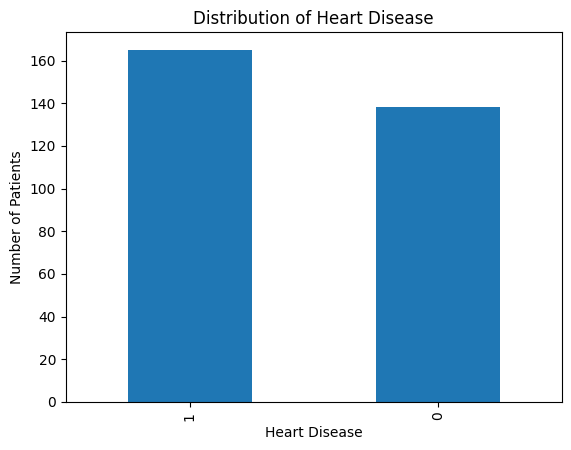

In [11]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.title("Distribution of Heart Disease")
plt.show()

In [12]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
9,oldpeak,0.128485
7,thalach,0.119725
11,ca,0.115533
2,cp,0.103792
12,thal,0.093300
0,age,0.092811
3,trestbps,0.077537
8,exang,0.075809
4,chol,0.074812
10,slope,0.051058


In [13]:
new_patient = [[55,1,2,140,250,0,1,160,0,1.2,1,0,2]]

prediction = model.predict(new_patient)

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [14]:
import joblib

joblib.dump(model, "heart_model.pkl")

['heart_model.pkl']